In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from IPython.display import display

from tqdm import tqdm

import pandas as pd

from scipy import stats

from scipy.ndimage import gaussian_filter

import pyunfold as pu

from scipy.io import loadmat
from scipy.interpolate import interp1d

from scipy.linalg import orth

In [2]:
axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '12' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
def T(A):
    return np.swapaxes(A, -2, -1)

## Dome C Site Data & Production Rates

We set up a Propagator for the Dome C site and load pre-calculated Production Rates

In [4]:
site = 'DomeC'
Prop = Propagator()
density_model = ('MSIS00', ('SouthPole', 'January'))

df_Pfast = pd.read_csv('Production Rates/P_fast_SouthPole_3120m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_SouthPole_3120m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

# The only production model being used is Heisinger
i = model_names.index('Heisinger')
prod_cut = np.arange(len(P_14C))[i:i+1]

Prop.Phi['prod']=P_14C[prod_cut]
C_flow_response = F.flow_14C_response(Prop)[0]
C_response = C_flow_response @ Prop.S_mat[Prop.i_start:]

z_samp = Prop.z_samp

## Setting Up Time Bins

We separate our time bins into two sections:

Our high-sensitivity region ($\sim$7 kya to present) which affects both Dome C and Taylor Glacier $^{14}$CO levels, and where we use a bin-width of 1 year.

Our low-sensitivity region ($\sim$50 kya to $\sim$7 kya) which only affects the equilibirum level of $^{14}$CO at Taylor Glacier before the start of integration, and where we use a bin-width of 100 years.

In [111]:
# Dome C Time Bins
dt_DC = Prop.dt[0]
t_bins_DC = Prop.t_bins[Prop.i_start:]-Prop.t_bins[-1]
t_DC = Prop.t[Prop.i_start:]-Prop.t_bins[-1]
Period_DC = t_bins_DC[-1]-t_bins_DC[0]

# Taylor Glacier Time Bins
dt_TG_short = 1
dt_TG_long = 100
Period_TG_short = Period_DC
Period_TG = 50000

t_bins_TG_short = -np.flip(np.arange(0, Period_TG_short+dt_TG_short, dt_TG_short)) # time integration steps
t_TG_short = (t_bins_TG_short[:-1]+t_bins_TG_short[1:])/2
t_bins_TG_long = -np.flip(np.arange(-t_bins_TG_short[0], Period_TG+dt_TG_long, dt_TG_long))
t_TG_long = (t_bins_TG_long[:-1]+t_bins_TG_long[1:])/2

t_bins_TG = np.concatenate((t_bins_TG_long[:-1], t_bins_TG_short))
t_TG = (t_bins_TG[:-1]+t_bins_TG[1:])/2
dt_TG = np.diff(t_bins_TG)

# Full Model Time Bins
Period = Period_TG
t_bins = t_bins_TG
t = t_TG
dt = dt_TG

t_scale = t/Period_DC # time scaled from -1 to 0, with 0=present

f_interp_to_DC = ((t_bins[1:].reshape((-1,1))-t_bins_DC[:-1].reshape((1,-1))).clip(0,dt_DC) - (t_bins[:-1].reshape((-1,1))-t_bins_DC[:-1].reshape((1,-1))).clip(0,dt_DC))/dt_DC
f_interp_to_TG = ((t_bins[1:].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG) - (t_bins[:-1].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG))/dt_TG

## Taylor Glacier Site Data & Production Rates

We set up a Propagator for the Taylor Glacier site and load pre-calculated Production Rates

In [6]:
# sets the conditions for the study at Taylor Glacier by Dyonisius et al. (https://tc.copernicus.org/articles/17/843/2023/)
Prop_TG = Propagator(pressure=9.248658001389917e+04, # (Pa) pressure used in Taylor Glacier analysis "from LSD ERA reanalysis"
              elev=526, # (m) elevation listed in Figure 1 caption of Taylor Glacier study (need to confirm)
              rho_ice=0.92) # (g/cm^3) density used in Taylor Glacier analysis
h_bins_TG = np.arange(0, 1001, 1)
Prop_TG.set_mass_depth(z_bins=h_bins_TG/Prop_TG.rho_ice, h_bins=h_bins_TG, z_min=0., z_deep=h_bins_TG[-1]/Prop_TG.rho_ice)
# sample mid depths = [6.85, 10., 15, 19.5, 40.5, 51, 61.5, 72.]
density_model = ('MSIS00', ('SouthPole', 'January'))

df_Pfast_TG = pd.read_csv('Production Rates/P_fast_TaylorGlacier_526m.csv')
df_Pneg_TG = pd.read_csv('Production Rates/P_neg_TaylorGlacier_526m.csv')
P_14C_TG = np.swapaxes([df_Pfast_TG.T, df_Pneg_TG.T], 0, 1)
model_names_TG = list(df_Pfast_TG.columns)

# The only production model being used is Heisinger
i = model_names_TG.index('Heisinger')
prod_cut_TG = np.arange(len(P_14C_TG))[i:i+1]

flow = 'sample'
flowpath = loadmat('matlab/MC_14CO_mod/flowpath_{}.mat'.format(flow))
age = flowpath['age'][0]

Prop_TG.Phi['prod']=P_14C_TG[prod_cut_TG]
C_response_TG, C_init_TG = F.Taylor_flow_response(Prop_TG, flow, t_bins=t_bins_TG)
C_response_TG = C_response_TG[0,0]
C_init_TG = C_init_TG[0,0]

TG_data = loadmat('matlab/MC_14CO_mod/TG_data_14CO.mat')
CO_exp_TG_data = TG_data['CO_molec'][3:,0]
CO_err_TG_data = TG_data['CO_molec_err'][3:,0]/2.
z_samp_TG = TG_data['sample_depth_CO'][3:,0]

## Set Up $^{14}$CO Response Matrices

The response function for $^{14}$CO observed at present depth $z$ that was produced at time $t$ by production mode $m$ is:

$$C_m(z,t) = P_m(z'(z,t))$$

where $z'(z,t)$ is the depth an ice parcel had at time $t$ if its current depth is $z$.

We can find the response for the $^{14}$CO concentration of a sample by averaging over the sample's mass depth range $h(z) = \int_0^z \rho(z') dz'$.

$$C_{z m}(t) = \frac{1}{h_{z+}-h_{z-}} \int_{h_z-}^{h_{z+}} P_m(z'(h, t))\, dh$$

Where $h_{z-}$ are the lower bounds and $h_{z+}$ are the upper bounds of the sample mass depth bins.

The $^{14}$CO concentration of each sample is then:

$$\vec{c}_z = \sum_m \vec{f}_m \int \phi(t) C_{z m}(t) \, dt$$

Where $\vec{f}_m$ are the scaling factors for each production mode, and $\phi(t)$ is the scaling of the total muon flux as a function of time.

Adding a binning scheme for time, this becomes:

$$\vec{c}_z = \sum_m \sum_t \vec{f}_m \vec{\phi}_t C_{z m t}; \qquad C_{z m t} = C_{z m}(t_t) \, dt_t$$

$C_{z m t}$ is the full $^{14}$CO response matrix given $P_m(z)$, $z'(z,t)$, and $h(z)$.  I'll generally just refer to it as $C$.

Given a known set of f-factors $\vec{f}$, the $^{14}$CO response matrix becomes 

$$C_{z t}(\vec{f}) = \sum_m C_m \vec{f}_m$$

Given a known muon flux $\vec{\phi}$, the $^{14}$CO response matrix becomes 

$$C_{z m}(\vec{\phi}) = \sum_t C_t \vec{\phi}_t$$

In [7]:
# True f-factors (fast, neg)
f_true = np.array([0.08,0.06])
#f_true = np.array([0.,1.])

# Response Matrices for f_true
CO_response = f_interp_to_DC @ (f_true @ np.swapaxes(C_response, -3,-2))
CO_response_TG = f_interp_to_TG @ (f_true @ np.swapaxes(C_response_TG, -3,-2))
CO_response_all = np.concatenate((CO_response, CO_response_TG), axis=-1)

# In an ideal world, CO_init would be part of CO_response
CO_init_TG = f_true @ C_init_TG
CO_init_all = np.concatenate((np.zeros(len(z_samp)), CO_init_TG), axis=-1)
CO_response_TG[0] += CO_init_TG
CO_response_all[0] += CO_init_all

# Response Matrix for constant flux, unknown f
C0 = np.sum(C_response, axis=-2)
C0_TG = np.sum(C_response_TG, axis=-2)
C0_TG += C_init_TG
C0_all = np.concatenate((C0, C0_TG), axis=-1)

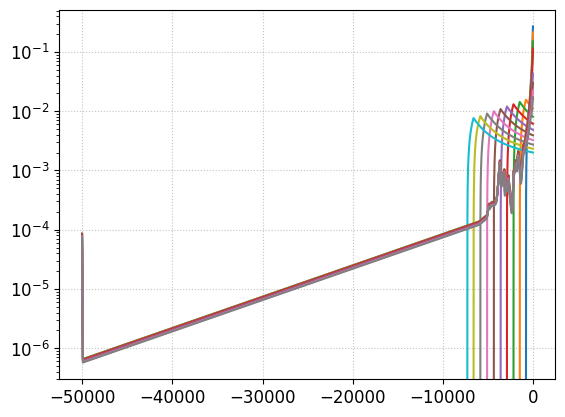

In [8]:
plt.plot(t, CO_response_all/dt.reshape((-1,1)))
plt.yscale('log')
plt.show()

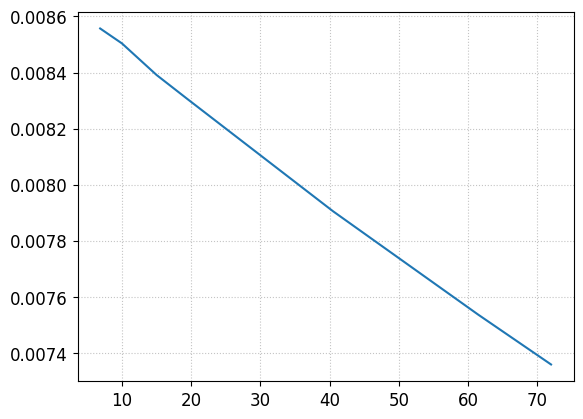

In [9]:
plt.plot(z_samp_TG, CO_init_TG)

## Baseline $^{14}$CO Prediction

We start from a baseline assumption of a pair of true f-factors $\vec{f}_0$ and a constant muon flux $\vec{\phi}_0 = \vec{1}$.

In this case, we would measure a $^{14}$CO concentration of:
$$\vec{c}_{\text{exp}} = C(\vec{f}_0)\vec{\phi}_0 + \Delta \vec{c}_{\text{err}}$$

With a systematic error of
$$\vec{\sigma}_{z} = \vec{r}_z \vec{c}_z$$

Where $\vec{r}$ is the relative error at each sample depth.

We're going to examine our sensitivity to perturbations on $\vec{\phi}_{0}$, with the simplifying assumption that $C(\vec{f}_0) \Delta \vec{\phi}  \ll \vec{c}$, and therefore $\Delta\vec{\sigma} \ll \vec{\sigma}$, so the uncertainties are essentially unchanged.

We'll also assume that $\Delta \vec{c}_{\text{err}} \ll \vec{c}$, so $\vec{\sigma}_z \approx \vec{r}_z C(\vec{f}_0)_z \vec{\phi}_0$, and the magitude of the reported systematic errors are unchanged by the actual experimental error experienced in the measurement.

Under these assumptions, we can calculate a single baseline covariance matrix between our $^{14}$CO samples, $\Sigma$.

The diagonals of $\Sigma$ are the variances of our baseline measurement, while the offdiagonals are the product of the uncertainties and the correlation, so

$$\Sigma = \vec{\sigma}\vec{\sigma}^T * \text{Corr.} = \vec{c}R R^T \vec{c}^T * \text{Corr.} = \vec{\phi}C R^2 C^T \vec{\phi}^T * \text{Corr.}$$

Where we perform an element-wise multiplication between the outer product of our uncertainties and the correlation matrix of our measurement.

Until someone tells me otherwise, I'll just use $\text{Corr.} = I$.

By taking the inverse of our covariance matrix, we can calculate the $\chi^2$ between a predicted $\hat{c}$ and observed $\vec{c}$:

$$\chi^2 = (\vec{c}-\hat{c})^T\Sigma^{-1}(\vec{c}-\hat{c})$$

In [140]:
# Baseline 14CO Profiles
CO_base = f_true @ C0
CO_base_TG = f_true @ C0_TG
CO_base_all = np.concatenate((CO_base, CO_base_TG), axis=-1)

rel_err = 0.02 # relative error @ Dome C
rel_cov = np.identity(len(z_samp)) # correlations between sample errors @ Dome C

rel_err_TG = np.mean(CO_err_TG_data/CO_exp_TG_data) # average relative error @ Taylor Glacier
rel_cov_TG = np.identity(len(z_samp_TG)) # correlations between sample errors @ Taylor Glacier

# Baseline 14CO Experimental Uncertainties
dCO_base = np.abs(CO_base * rel_err)
dCO_base_TG = np.abs(CO_base_TG * rel_err_TG)
dCO_base_all = np.concatenate((dCO_base, dCO_base_TG), axis=-1)

In [141]:
# Covariance Matrices

Sigma_base = dCO_base.reshape((-1, 1))*dCO_base.reshape((1,-1)) * rel_cov
#Sigma_base[np.arange(len(z_samp)),np.arange(len(z_samp))] = dCO_base**2
Sigma_inv_base = np.linalg.inv(Sigma_base)

Sigma_base_TG = dCO_base_TG.reshape((-1,1))*dCO_base_TG.reshape((1,-1)) * rel_cov_TG
#Sigma_base_TG[np.arange(len(z_samp_TG)),np.arange(len(z_samp_TG))] = dCO_base_TG**2
Sigma_inv_base_TG = np.linalg.inv(Sigma_base_TG)

Sigma_base_all = np.zeros((*dCO_base_all.shape,len(z_samp)+len(z_samp_TG)))
Sigma_base_all[:len(z_samp),:len(z_samp)] = Sigma_base
Sigma_base_all[len(z_samp):,len(z_samp):] = Sigma_base_TG
Sigma_inv_base_all = np.zeros((*dCO_base_all.shape,len(z_samp)+len(z_samp_TG)))
Sigma_inv_base_all[:len(z_samp),:len(z_samp)] = Sigma_inv_base
Sigma_inv_base_all[len(z_samp):,len(z_samp):] = Sigma_inv_base_TG

## Null Model Best Fit

We define our null model as one where the muon flux is constant, $\vec{\phi}_0 = \vec{1}$, but the f-factors, $\vec{f}$, are allowed to vary.

To find the best-fit for our null model, we need to know the f-factors $\hat{f}$ which minimize the $\chi^2$:

$$\chi^2_{\text{null}} = (\vec{c}-C_0 \hat{f})^T\Sigma^{-1}(\vec{c}-C_0 \hat{f}))$$

where $C_0 = C(\vec{\phi}_0)$.

To find the best-fit f-factors, we can use the pseudoinverse in $\chi$-space.

Because $\Sigma^{-1}$ is symmetric, it can be split into to transformation matrices $D^T D$, where $D^T$ is the eigenvectors of $\Sigma^{-1}$ scaled by the squareroot of their eigenvalue ($1/\sigma$).  The effect of the transformation $D\vec{c}$ is to transform our sample into $\chi$-space, where the uncertainties are uniform, and therefore the $\chi^2$ is equivalent to the square of the euclidean norm.

Applying the pseudoinverse while in $\chi$-space minimizes the euclidean norm and therefore the $\chi^2$.  So,

$$\hat{c} = DC_0 \hat{f}$$

$$\hat{f} = (DC_0)^+ D \vec{c}$$
$$= (C_0^T D^T D C_0)^{-1} C_0^T D^T D \vec{c}$$
$$= (C_0^T \Sigma^{-1} C_0)^{-1} C_0^T \Sigma^{-1} \vec{c}$$
$$= \hat{F}\vec{c}$$

$$\hat{F} = (C_0^T \Sigma^{-1}C_0)^{-1} C_0^T \Sigma^{-1}$$

Gives us the transformation matrix from our experimental $\vec{c}$ to our best fit f-factors $\hat{f}$.

In [12]:
# Best-fit constant f-factor transformation matrices
F_hat = np.linalg.inv(C0 @ Sigma_inv_base @ T(C0)) @ C0 @ Sigma_inv_base
F_hat_TG = np.linalg.inv(C0_TG @ Sigma_inv_base_TG @ T(C0_TG)) @ C0_TG @ Sigma_inv_base_TG
F_hat_all = np.linalg.inv(C0_all @ Sigma_inv_base_all @ T(C0_all)) @ C0_all @ Sigma_inv_base_all

The best-fit $^{14}$CO prediction is then:

$$\hat{c} = C_0 \hat{f} = C_0 \hat{F}\vec{c} = \hat{C}\vec{c}$$

$$\hat{C} = C_0 \hat{F}$$

In [13]:
# Best-fit constant 14CO transformation matrices
C_hat = T(C0) @ F_hat
C_hat_TG = T(C0_TG) @ F_hat_TG
C_hat_all = T(C0_all) @ F_hat_all

And so our best fit $\chi^2$ is:

$$\chi^2_{\text{null}} = \vec{c}^T(I-\hat{C})^T\Sigma^{-1}(I-\hat{C})\vec{c}$$
$$= \vec{c}^T(I-\hat{C})^T(\Sigma^{-1}-\Sigma^{-1}\hat{C})\vec{c}$$
$$= \vec{c}^T(\Sigma^{-1}-\Sigma^{-1}\hat{C} - \hat{C}^T\Sigma^{-1} + \hat{C}^T\Sigma^{-1}\hat{C})\vec{c}$$

We can show that $\Sigma^{-1}\hat{C}$ is symmetric by writing it out in full:

$$\Sigma^{-1}\hat{C} = \Sigma^{-1} C_0 (C_0^T \Sigma^{-1}C_0)^{-1} C_0^T \Sigma^{-1}$$

And therefore we can simplify:

$$\chi^2_{\text{null}} = \vec{c}^T(\Sigma^{-1}-2\Sigma^{-1}\hat{C} + \Sigma^{-1}\hat{C}^2)\vec{c}$$
$$= \vec{c}^T\Sigma^{-1}(I-2\hat{C}+\hat{C}^2)\vec{c}$$

Because $\hat{C}$ is a projection matrix, it follows $\hat{C}^2 = \hat{C}$, and:

$$\chi^2_{\text{null}} = \vec{c}^T\Sigma^{-1}(I-\hat{C})\vec{c}$$
$$ = \vec{c}^T X_{\text{null}} \vec{c}$$

$$X_{\text{null}} = \Sigma^{-1}(I-\hat{C})$$

Our $X_{\text{null}}$ matrix here acts as a modification on the inverse covariance, accounting for the reduction in $\chi^2$ from fitting our null model.

In [14]:
# Best-fit constant chi^2 matrices
Chi2_fit = Sigma_inv_base @ (np.identity(len(C_hat)) - C_hat)
Chi2_fit_TG = Sigma_inv_base_TG @ (np.identity(len(C_hat_TG)) - C_hat_TG)
Chi2_fit_all = Sigma_inv_base_all @ (np.identity(len(C_hat_all)) - C_hat_all)

If we now look at how our perturbed $\vec{\phi}$ affects the $\chi^2$:

$$\chi^2_{\text{null}} = \vec{c}^T X_{\text{null}} \vec{c}$$
$$= (C_f\vec{\phi} + \Delta\vec{c}_{\text{err}})^T X_{\text{null}} (C_f\vec{\phi} + \Delta\vec{c}_{\text{err}})$$
$$= \vec{\phi}^T C_f^T X_{\text{null}} C_f \vec{\phi} + 2\Delta\vec{c}_{\text{err}}^TX_{\text{null}}C_f\vec{\phi} + \Delta\vec{c}_{\text{err}}^TX_{\text{null}} \Delta\vec{c}_{\text{err}}$$
$$= \vec{\phi}^T C_f^T X_{\text{null}} C_f \vec{\phi} + \Delta\chi^2_{\text{err}}(\vec{\phi})$$
$$= \vec{\phi}^T \hat{X}_{\text{null}} \vec{\phi} + \Delta\chi^2_{\text{err}}(\vec{\phi})$$

where

$$\hat{X}_{\text{null}} = C_f^T X_{\text{null}} C_f = C_f^T (\Sigma^{-1} - \Sigma^{-1} C_0 (C_0^T \Sigma^{-1}C_0)^{-1} C_0^T \Sigma^{-1}) C_f$$

Is the effective inverse covariance matrix for $\vec{\phi}$, (or as I've been referring to it, the Time-Sensitivity Matrix).

Next we will prove that the average (be it mean or median) value of $\Delta\chi^2_{\text{err}}(\vec{\phi})$ - the contribution to the $\chi^2$ from systematic error - is constant with respect to $\vec{\phi}$, and approximately equal to the number of degrees of freedom.

I justify this approximation by the fact that, analagous to $\Sigma^{-1}$, the symmetric matrix $X_{\text{null}}$ can be broken into $X_{\text{null}} = D_{\text{null}}^T D_{\text{null}}$ to provide a transformation into $\chi_\text{null}$-space.  Thus:
$$\Delta\chi^2_{\text{err}}(\vec{\phi}) = 2\Delta\vec{c}_{\text{err}}^TX_{\text{null}}C_f\vec{\phi} + \Delta\vec{c}_{\text{err}}^TX_{\text{null}} \Delta\vec{c}_{\text{err}}$$
$$= 2\Delta\vec{c}_{\text{err}}^T D_{\text{null}}^T D_{\text{null}} C_f\vec{\phi} + \Delta\vec{c}_{\text{err}}^TD_{\text{null}}^T D_{\text{null}} \Delta\vec{c}_{\text{err}}$$
$$= 2 \Delta\vec{\chi}_{\text{err}}^T\hat{\chi} + |\Delta\vec{\chi}_{\text{err}}|^2$$

The vector $\Delta\vec{\chi}_{\text{err, null}}$ is the projection of the original $\Delta\vec{\chi}_{\text{err}} = D\Delta\vec{c}_{\text{err}}$ vector, which is distributed as an N-dimensional normal function with standard deviation of 1 in all directions.  Our $\Delta\vec{\chi}_{\text{err, null}}$ should therefore be spherically symmetric in its distribution (within our subspace), meaning for any value of $\Delta\vec{\chi}_{\text{err}}^T\hat{\chi}$ there exists an equally likely value that is its negative.

Therefore, the both the mean and median values of $\Delta\vec{\chi}_{\text{err}}^T\hat{\chi}$ are 0, and the median value of $|\Delta\vec{\chi}_{\text{err}}|^2$ is the median of a $\chi^2$ distribution, which is approximately equal to the number of degrees of freedom.  (The mean, if you're interested, is EXACTLY the number of degrees of freedom!)

Therefore, the median value of the $\chi^2$ expected from a measurement for a given $\vec{\phi}$ is:

$$\chi^2_{\text{null, med.}} = \vec{\phi}^T \hat{X}_{\text{null}} \vec{\phi} + \Delta\chi^2_{\text{err, med.}}$$
$$\approx \vec{\phi}^T \hat{X}_{\text{null}} \vec{\phi} + \text{d.o.f.}$$

In [15]:
# Best-fit null model chi^2 matrix (phi -> chi^2_null)
X = CO_response @ Chi2_fit @ CO_response.T
X_TG = CO_response_TG @ Chi2_fit_TG @ CO_response_TG.T
X_all = CO_response_all @ Chi2_fit_all @ CO_response_all.T

/tmp/ipykernel_782/31298462.py:14: RuntimeWarning: invalid value encountered in divide
  im = ax2.imshow(X_mat/(x_mag * T(x_mag)), origin='lower', aspect='auto', interpolation='none', extent=(-len(t), 0, -len(t), 0))


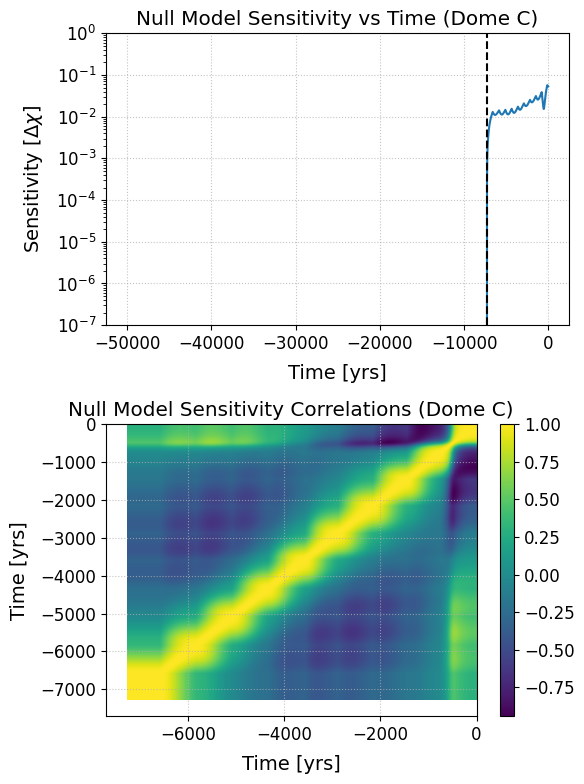

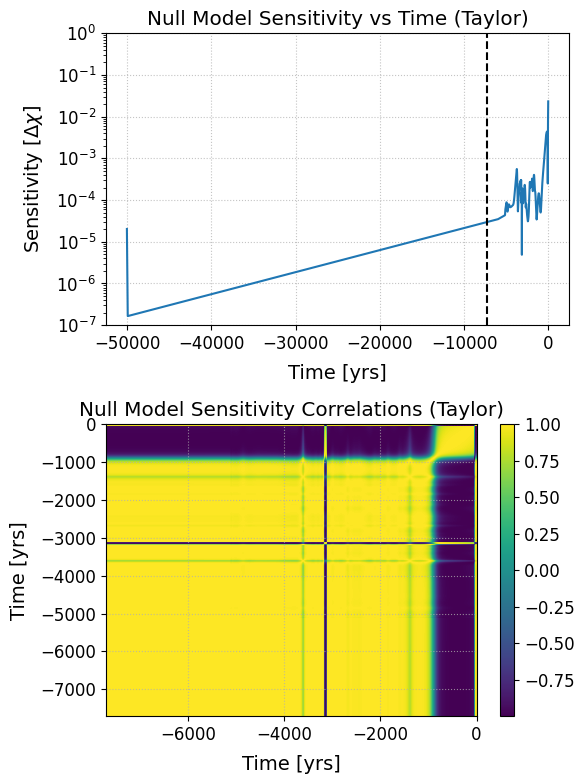

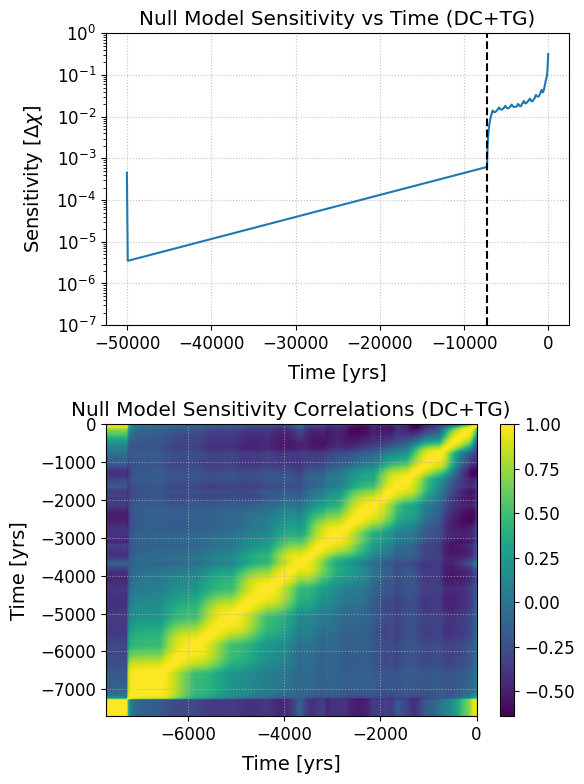

In [60]:
sites = ['Dome C', 'Taylor', 'DC+TG']

for i,X_mat in enumerate([X, X_TG, X_all]):

    x_mag = np.sqrt(np.diag(X_mat)).reshape((-1,1))

    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(6,8), tight_layout=True)

    ax1.plot(t, x_mag[:,0]/dt)
    ax1.axvline(t_bins_DC[0], ls='--', c='k')
    #cont = ax2.contourf(t,t, X/(x_mag * T(x_mag)), alpha=0.8)
    #plt.colorbar(cont)

    im = ax2.imshow(X_mat/(x_mag * T(x_mag)), origin='lower', aspect='auto', interpolation='none', extent=(-len(t), 0, -len(t), 0))
    plt.colorbar(im)

    ax1.set(xlabel='Time [yrs]',
               #xscale='log',
               ylabel=r'Sensitivity [$\Delta \chi$]',
               yscale='log',
               title = 'Null Model Sensitivity vs Time ({})'.format(sites[i]),
               ylim = (1e-7,1),
          )
    ax2.set(xlabel='Time [yrs]',
               #xscale='log',
               ylabel='Time [yrs]',
               #yscale='log',
               title = 'Null Model Sensitivity Correlations ({})'.format(sites[i]),
          )

    plt.show()

## Amplitude

We define the Amplitude $A_B(\vec{\phi})$ of a muon flux $\vec{\phi}$ as the standard deviation under a blur $B$, with a set of weights $\vec{w}$ on our blurred bins, s.t. $\sum \vec{w} = 1$.

$$A_B(\vec{\phi}) = \sqrt{\vec{\phi}^T B^T (I-W_{\text{avg}})^T W_{\text{std}}(I-W_{\text{avg}}) B\vec{\phi}}$$

where $W_{\text{std}}$ is the diagonal matrix of $\vec{w}$, and $W_{\text{avg}}$ is a square matrix with its rows filled by $\vec{w}$.  The result being that $\vec{\phi}^T W_{\text{std}} \vec{\phi} = \text{std}(\vec{\phi})$ and $W_{\text{avg}}\vec{\phi} = \text{avg}(\vec{\phi})$, repeated along a column.

We can simplify this by first expanding,

$$A_B(\vec{\phi}) = \sqrt{\vec{\phi}^T B^T (W_{\text{std}} - W_{\text{avg}}^T W_{\text{std}} - W_{\text{std}}W_{\text{avg}} + W_{\text{avg}}^T W_{\text{std}}W_{\text{avg}}) B\vec{\phi}}$$

Note that $W_{\text{std}}W_{\text{avg}} = W_{\text{avg}}^T W_{\text{std}} = \vec{w}\vec{w}^T$, and $W_{\text{avg}}^2 = W_{\text{avg}}$.  This is left as an exercise for the reader.

$$A_B(\vec{\phi}) = \sqrt{\vec{\phi}^T B^T (W_{\text{std}} - 2\vec{w}\vec{w}^T + W_{\text{std}}W_{\text{avg}}W_{\text{avg}}) B\vec{\phi}}$$
$$= \sqrt{\vec{\phi}^T B^T W_{\text{std}}(I - \vec{w}\vec{w}^T) B\vec{\phi}}$$
$$= \sqrt{\vec{\phi}^T A_B\vec{\phi}}$$

$$A_B = B^T W_{\text{std}}(I - \vec{w}\vec{w}^T) B$$

Important properties of this definition of the amplitude:
$$A_B(\vec{0}) = 0; \qquad A_B(a\vec{\phi} + \vec{1}) = a A_B(\vec{\phi})$$

This follows from the requirement that the blur $B$ preserves the average of $\vec{\phi}$, and that $B\vec{1} = \vec{1}$.

In [143]:
# Blur Matrix
#Blur = np.exp(-((t.reshape((-1,1))-t.reshape((1,-1)))/(Period_DC/20))**2/2) *dt.reshape((1,-1)) / np.sqrt(2*np.pi) / (Period_DC/20)
Blur = np.zeros((len(t),len(t)))
Blur[-len(t_DC):, -len(t_DC):] = np.exp(-((t_DC.reshape((-1,1))-t_DC.reshape((1,-1)))/(Period_DC/20))**2/2) *dt_DC.reshape((1,-1)) / np.sqrt(2*np.pi) / (Period_DC/20)
Blur[:-len(t_DC), :-len(t_DC)] = 1.
Blur /= np.sum(Blur, axis=0, keepdims=True)

# Amplitude Matrix
weights = np.copy(dt)
weights[t<t_bins_DC[0]] = 1.
weights = weights/np.sum(weights)
#A_B = Blur @ T(np.identity(len(t)) - weights.reshape((1,-1))) @ np.diag(weights) @ (np.identity(len(t)) - weights.reshape((1,-1))) @ T(Blur)
A_B = Blur @ (np.identity(len(t)) - weights.reshape((1,-1)) * weights.reshape((-1,1))) @ T(Blur)

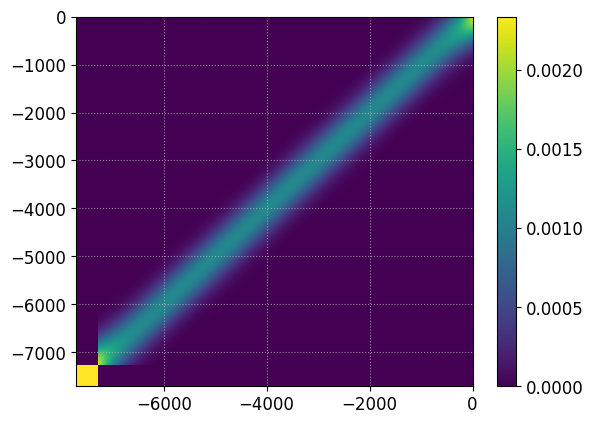

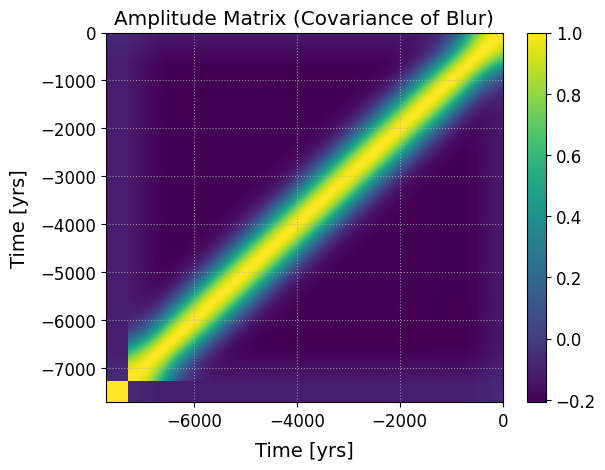

In [139]:
#plt.contourf(t,t, Blur, alpha=0.8)
#plt.colorbar()
im = plt.imshow(Blur, origin='lower', aspect='auto', interpolation='none', extent=(-len(t), 0, -len(t), 0))
plt.colorbar(im)
plt.show()

a = np.sqrt(np.diag(A_B)).reshape((-1,1))
#plt.contourf(t,t, A_B/(a*a.T), alpha=0.8)
#plt.colorbar()
im = plt.imshow(A_B/(a*a.T), origin='lower', aspect='auto', interpolation='none', extent=(-len(t), 0, -len(t), 0))
plt.colorbar(im)
plt.xlabel('Time [yrs]')
plt.ylabel('Time [yrs]')
plt.title('Amplitude Matrix (Covariance of Blur)')
plt.show()

In [65]:
flux_noise = np.random.normal(0., 1/np.sqrt(dt), (len(t)))

Smooth_ish = np.exp(-((t.reshape((-1,1))-t.reshape((1,-1)))/(Period_DC/100))**2/2)
Smooth_ish /= np.sum(Smooth_ish, axis=0, keepdims=True)

flux_smooth_ish = flux_noise @ Smooth_ish
flux_smooth_ish += 1-flux_smooth_ish[-1]
flux_blur = flux_smooth_ish @ Blur

CO_smooth_ish = flux_smooth_ish @ CO_response
CO_blur = flux_blur @ CO_response

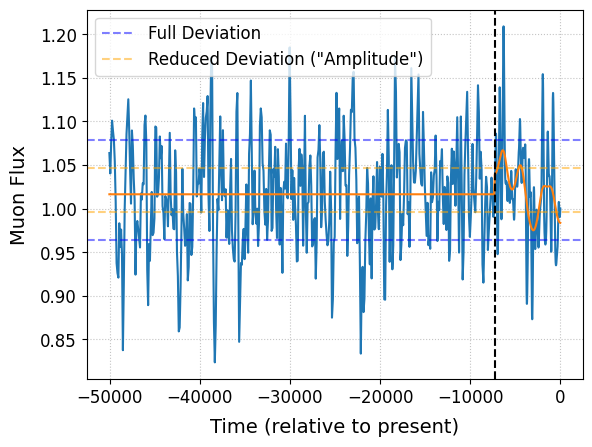

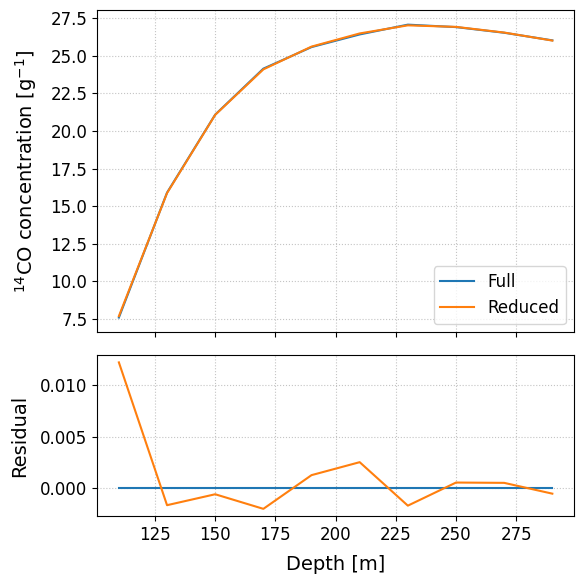

In [66]:
plt.plot(t, flux_smooth_ish)
plt.plot(t, flux_blur)

plt.axhline(np.average(flux_smooth_ish, weights=weights)+np.std(flux_smooth_ish), ls='--', c='b', alpha=0.5, label='Full Deviation')
plt.axhline(np.average(flux_smooth_ish, weights=weights)-np.std(flux_smooth_ish), ls='--', c='b', alpha=0.5)

plt.axhline(np.average(flux_blur, weights=weights)+np.std(flux_blur), ls='--', c='orange', alpha=0.5, label='Reduced Deviation ("Amplitude")')
plt.axhline(np.average(flux_blur, weights=weights)-np.std(flux_blur), ls='--', c='orange', alpha=0.5)
plt.axvline(t_bins_DC[0], ls='--', c='k')

plt.xlabel('Time (relative to present)')
plt.ylabel('Muon Flux')
plt.legend()
plt.show()

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(Prop.z_samp, CO_smooth_ish, label='Full')
ax1.plot(Prop.z_samp, CO_blur, label='Reduced')

ax2.plot(Prop.z_samp, CO_smooth_ish / CO_smooth_ish -1)
ax2.plot(Prop.z_samp, CO_blur / CO_smooth_ish -1)

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
#ax1.title.set_text('(Dome C)')
ax1.legend(loc='lower right')

plt.show()

In [144]:
#A_noB = T(np.identity(len(t)) - weights.reshape((1,-1))) @ np.diag(weights) @ (np.identity(len(t)) - weights.reshape((1,-1)))
A_noB = (np.identity(len(t)) - weights.reshape((1,-1)) * weights.reshape((-1,1)))

In [68]:
vals, vecs = np.linalg.eig(A_B)

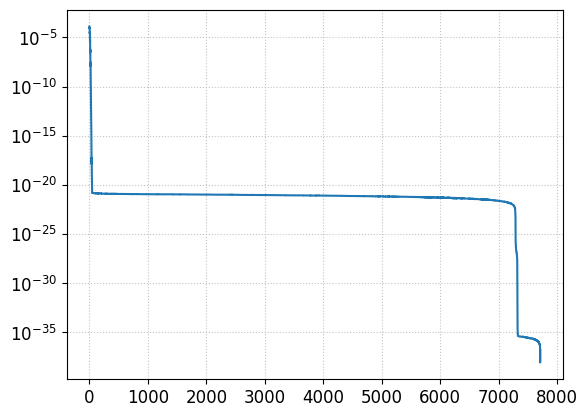

In [69]:
plt.plot(np.abs(vals))
plt.yscale('log')

In [70]:
np.sum(np.abs(vals)>1e-4)

np.int64(4)

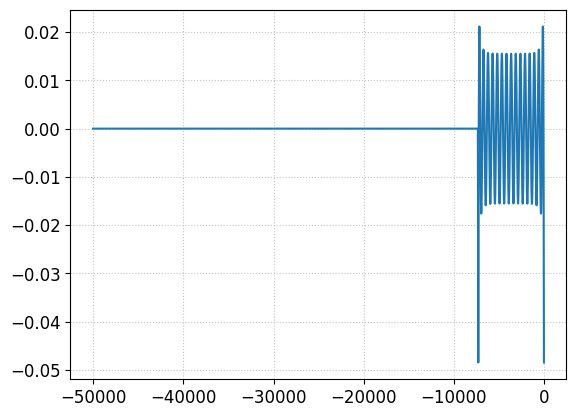

In [71]:
plt.plot(t, vecs[:,30])

In [72]:
vals2, vecs2 = np.linalg.eig(A_noB)

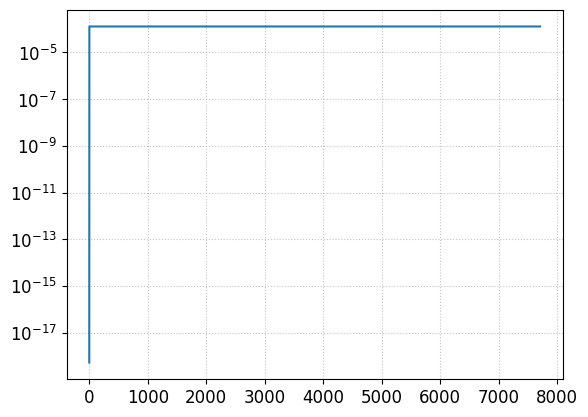

In [73]:
plt.plot(np.abs(vals2))
plt.yscale('log')

## Random Flux Model

We generate a random muon flux by filling our time bins with noise pulled from a normal distribution with a standard deviation of $dt^{-1/2}$ where $dt$ is the width of the time bin in years.

We then smooth the noise by applying a gaussian blur with a standard deviation, arbitrarily chosen to be 1/10 the period of our Dome C timeline.

Finally, we scale the smoothed flux to have a chosen amplitude, and add a constant value so that the flux converges to 1 in the present (as the muon flux flux is defined relative to present day).

In [231]:
Smooth = np.exp(-((t.reshape((-1,1))-t.reshape((1,-1)))/(Period_DC/50))**2/2)
Smooth /= np.sum(Smooth, axis=0, keepdims=True)

flux_noise = np.random.normal(0., 1/np.sqrt(dt), (len(t)))

flux_smooth = flux_noise @ Smooth

flux_scale = flux_smooth / np.sqrt(np.sum(flux_smooth @ A_B * flux_smooth, axis=-1, keepdims=True)) * 0.1
flux_scale += 1 - flux_scale[-1]

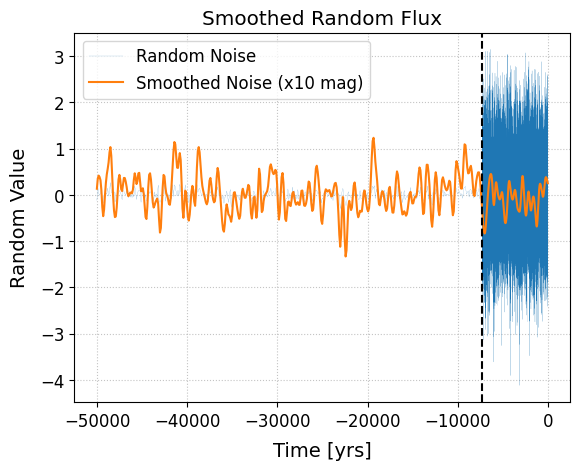

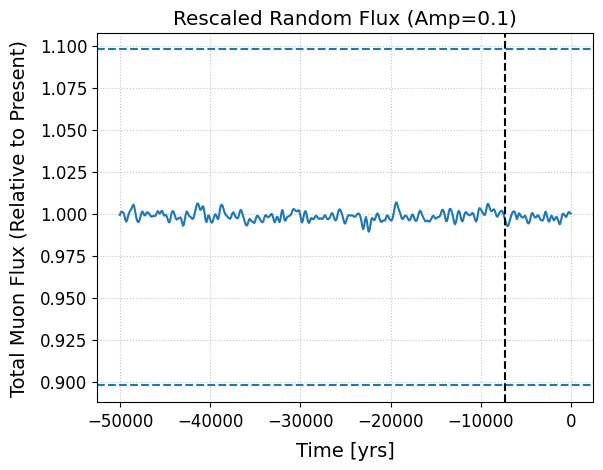

In [232]:
plt.plot(t, flux_noise, lw=0.1, label='Random Noise')
plt.plot(t, flux_smooth*10, label='Smoothed Noise (x10 mag)')
plt.axvline(t_bins_DC[0], ls='--', c='k')
plt.xlabel('Time [yrs]')
plt.ylabel('Random Value')
plt.legend()
plt.title('Smoothed Random Flux')
plt.show()

plt.plot(t, flux_scale)
plt.axhline(np.average(flux_scale, weights=weights)+0.1, ls='--')
plt.axhline(np.average(flux_scale, weights=weights)-0.1, ls='--')
plt.axvline(t_bins_DC[0], ls='--', c='k')
#plt.fill_between(t, np.mean(flux_scale)-0.1, np.mean(flux_scale)+0.1, alpha=0.5)
plt.xlabel('Time [yrs]')
plt.ylabel('Total Muon Flux (Relative to Present)')
plt.title('Rescaled Random Flux (Amp=0.1)')
plt.show()

In [233]:
N = 1000

flux_noise = np.random.normal(0., 1/np.sqrt(dt), (N, len(t)))

print('Smoothing flux...')
flux_smooth = flux_noise @ Smooth
print('Normalizing flux...')
flux_blur = flux_smooth @ Blur
flux_rand = flux_smooth/np.sqrt(np.sum(flux_smooth @ A_B * flux_smooth, axis=-1, keepdims=True))
#flux_rand += 1-flux_rand[:,-1:]
print('Done!')

Smoothing flux...
Normalizing flux...
Done!


## Gaussian Model

We define a gaussian model of the muon flux, with centers ranging anywhere over our Dome C timeline, and a "width" equal to twice the standard deviation.

The amplitude is as defined above.

In [134]:
w = 100
centers = np.linspace(t_DC[-1],t_DC[0],200)
flux_gauss = np.exp(-((centers.reshape((-1,1)) - t.reshape((1,-1)))/(w/2))**2/2)
#flux_gauss /= np.std(flux_gauss @ Blur, axis=-1, keepdims=True)

## Sensitivity Estimate
$$S(\vec{\phi}) = \frac{A_B(\vec{\phi})}{\sqrt{\chi^2(\vec{\phi})}} = \sqrt{\frac{\vec{\phi}^T A_B \vec{\phi}}{\vec{\phi}^T C^T X C \vec{\phi}}}$$

In [128]:
#phi_var = flux_rand

#phi_var = flux_gauss

phi_var = np.copy(t_scale).reshape((1,-1))#.clip(min=-1.)
phi_var[:,t<t_bins_DC[0]] = 0.

A_var = np.sqrt(np.sum(phi_var @ A_B * phi_var, axis=-1))
chi2 = np.sum(phi_var @ X * phi_var, axis=-1)
chi2_TG = np.sum(phi_var @ X_TG * phi_var, axis=-1)
chi2_all = np.sum(phi_var @ X_all * phi_var, axis=-1)
S = A_var/np.sqrt(chi2)
S_TG = A_var/np.sqrt(chi2_TG)
S_all = A_var/np.sqrt(chi2_all)

S_3 = S * np.sqrt(stats.chi2.isf(stats.norm.sf(3)*2., len(z_samp) - len(f_true)) - len(z_samp) + len(f_true))
S_5 = S * np.sqrt(stats.chi2.isf(stats.norm.sf(5)*2., len(z_samp) - len(f_true)) - len(z_samp) + len(f_true))

S_3TG = S_TG * np.sqrt(stats.chi2.isf(stats.norm.sf(3)*2., len(z_samp_TG) - len(f_true)) - len(z_samp_TG) + len(f_true))
S_5TG = S_TG * np.sqrt(stats.chi2.isf(stats.norm.sf(5)*2., len(z_samp_TG) - len(f_true)) - len(z_samp_TG) + len(f_true))

S_3all = S_all * np.sqrt(stats.chi2.isf(stats.norm.sf(3)*2., len(z_samp) + len(z_samp_TG)  - len(f_true)) - len(z_samp) - len(z_samp_TG)  + len(f_true))
S_5all = S_all * np.sqrt(stats.chi2.isf(stats.norm.sf(5)*2., len(z_samp) + len(z_samp_TG)  - len(f_true)) - len(z_samp)  - len(z_samp_TG) + len(f_true))

$$S_{5\sigma}(\vec{\phi}) = S(\vec{\phi}) \sqrt{\chi^2(5\sigma) - \Delta \chi^2_{\text{err}}} \approx S(\vec{\phi}) \sqrt{\chi^2(5\sigma) - \text{d.o.f.}} \approx 6.6 \, S(\vec{\phi})$$

In [129]:
# Sensitivity relative to General Amplitude
print('Dome C Sensitivity: \t\t\t {:.1f}% (3σ) \t {:.1f}% (5σ)'.format(np.median(S_3)*100, np.median(S_5)*100))
print()
print('Taylor Glacier Sensitivity: \t {:.1f}% (3σ) \t {:.1f}% (5σ)'.format(np.median(S_3TG)*100, np.median(S_5TG)*100))
print()
print('DC+TG Sensitivity: \t\t\t {:.1f}% (3σ) \t\t {:.1f}% (5σ)'.format(np.median(S_3all)*100, np.median(S_5all)*100))

Dome C Sensitivity: 			 18.4% (3σ) 	 28.0% (5σ)

Taylor Glacier Sensitivity: 	 446.4% (3σ) 	 688.9% (5σ)

DC+TG Sensitivity: 			 5.0% (3σ) 		 7.3% (5σ)


In [130]:
# Sensitivity relative to native amplitude
print('Dome C Sensitivity: \t\t\t {:.1f}% (3σ) \t {:.1f}% (5σ)'.format(np.median(S_3/A_var)*100, np.median(S_5/A_var)*100))
print()
print('Taylor Glacier Sensitivity: \t {:.1f}% (3σ) \t {:.1f}% (5σ)'.format(np.median(S_3TG/A_var)*100, np.median(S_5TG/A_var)*100))
print()
print('DC+TG Sensitivity: \t\t\t {:.1f}% (3σ) \t {:.1f}% (5σ)'.format(np.median(S_3all/A_var)*100, np.median(S_5all/A_var)*100))

Dome C Sensitivity: 			 61.9% (3σ) 	 94.1% (5σ)

Taylor Glacier Sensitivity: 	 1497.7% (3σ) 	 2311.3% (5σ)

DC+TG Sensitivity: 			 16.7% (3σ) 	 24.6% (5σ)


146.05116026464628


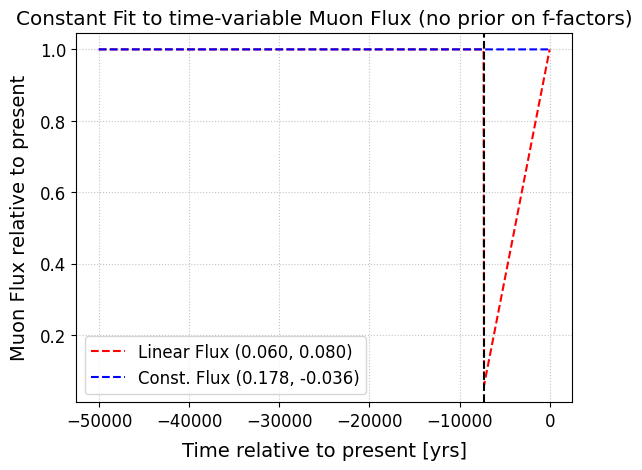

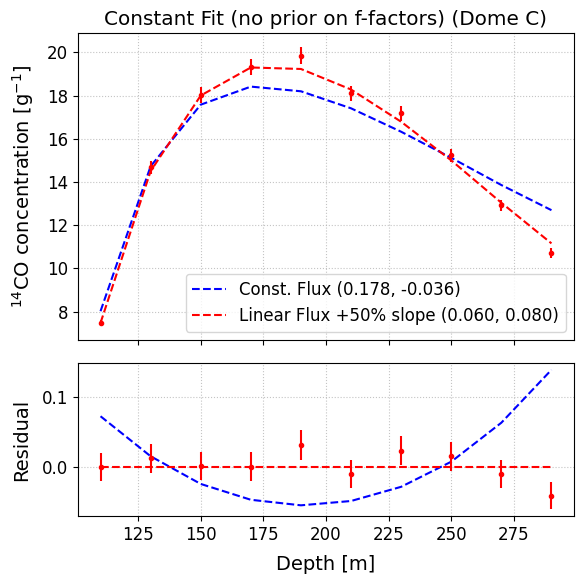

In [131]:
i = 0

flux_true = phi_var[i] * S_5[i] / A_var[i]
flux_true += 1-flux_true[-1]

CO_true = flux_true @ CO_response
s = np.random.normal(1, rel_err, (len(z_samp)))
CO_exp = CO_true * s
CO_err = np.abs(CO_exp * rel_err)

f_hat = F_hat @ CO_exp

print(np.sum(((C_hat @ CO_exp - CO_exp)/CO_err)**2))

plt.plot(t, flux_true, ls='--', c='r', label='Linear Flux ({1:.3f}, {0:.3f})'.format(*f_true))
plt.plot(t, t*0. + 1., ls='--', c='b', label='Const. Flux ({1:.3f}, {0:.3f})'.format(*f_hat))
plt.axvline(t_bins_DC[0], ls='--', c='k')
plt.xlabel('Time relative to present [yrs]')
plt.ylabel('Muon Flux relative to present')
plt.legend()
plt.title('Constant Fit to time-variable Muon Flux (no prior on f-factors)')
plt.show()

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex='col', sharey='row', height_ratios=[2,1])

ax1.plot(Prop.z_samp, f_hat @ C0, ls='--', c='b', label='Const. Flux ({1:.3f}, {0:.3f})'.format(*f_hat))
ax1.plot(Prop.z_samp, CO_true, ls='--', c='r', label='Linear Flux +50% slope ({1:.3f}, {0:.3f})'.format(*f_true))
ax1.errorbar(Prop.z_samp, CO_exp, yerr=CO_err, fmt='.', c='r')

ax2.plot(Prop.z_samp, f_hat @ C0 / CO_true -1, ls='--', c='b')
ax2.plot(Prop.z_samp, CO_true / CO_true -1, ls='--', c='r')
ax2.errorbar(Prop.z_samp, CO_exp / CO_true -1, yerr=np.abs(CO_err/ CO_true), fmt='.', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Constant Fit (no prior on f-factors) (Dome C)')
ax1.legend(loc='lower right')

plt.show()

In [135]:
phi_var = np.copy(flux_gauss)

A_var = np.sqrt(np.sum(phi_var @ A_B * phi_var, axis=-1))
chi2 = np.sum(phi_var @ X * phi_var, axis=-1)
chi2_TG = np.sum(phi_var @ X_TG * phi_var, axis=-1)
chi2_all = np.sum(phi_var @ X_all * phi_var, axis=-1)
S = A_var/np.sqrt(chi2)
S_TG = A_var/np.sqrt(chi2_TG)
S_all = A_var/np.sqrt(chi2_all)

S_3 = S * np.sqrt(stats.chi2.isf(stats.norm.sf(3)*2., len(z_samp) - len(f_true)) - len(z_samp) + len(f_true))
S_5 = S * np.sqrt(stats.chi2.isf(stats.norm.sf(5)*2., len(z_samp) - len(f_true)) - len(z_samp) + len(f_true))

S_3TG = S_TG * np.sqrt(stats.chi2.isf(stats.norm.sf(3)*2., len(z_samp_TG) - len(f_true)) - len(z_samp_TG) + len(f_true))
S_5TG = S_TG * np.sqrt(stats.chi2.isf(stats.norm.sf(5)*2., len(z_samp_TG) - len(f_true)) - len(z_samp_TG) + len(f_true))

S_3all = S_all * np.sqrt(stats.chi2.isf(stats.norm.sf(3)*2., len(z_samp) + len(z_samp_TG)  - len(f_true)) - len(z_samp) - len(z_samp_TG)  + len(f_true))
S_5all = S_all * np.sqrt(stats.chi2.isf(stats.norm.sf(5)*2., len(z_samp) + len(z_samp_TG)  - len(f_true)) - len(z_samp)  - len(z_samp_TG) + len(f_true))

# Sensitivity relative to General Amplitude
print('Dome C Sensitivity: \t\t\t {:.1f}% (3σ) \t {:.1f}% (5σ)'.format(np.median(S_3)*100, np.median(S_5)*100))
print()
print('Taylor Glacier Sensitivity: \t {:.1f}% (3σ) \t {:.1f}% (5σ)'.format(np.median(S_3TG)*100, np.median(S_5TG)*100))
print()
print('DC+TG Sensitivity: \t\t\t {:.1f}% (3σ) \t\t {:.1f}% (5σ)'.format(np.median(S_3all)*100, np.median(S_5all)*100))

Dome C Sensitivity: 			 7.7% (3σ) 	 11.8% (5σ)

Taylor Glacier Sensitivity: 	 1434.0% (3σ) 	 2213.1% (5σ)

DC+TG Sensitivity: 			 7.0% (3σ) 		 10.3% (5σ)


In [136]:
# Sensitivity relative to native amplitude
print('Dome C Sensitivity: \t\t\t {:.1f}% (3σ) \t {:.1f}% (5σ)'.format(np.median(S_3/A_var)*100, np.median(S_5/A_var)*100))
print()
print('Taylor Glacier Sensitivity: \t {:.1f}% (3σ) \t {:.1f}% (5σ)'.format(np.median(S_3TG/A_var)*100, np.median(S_5TG/A_var)*100))
print()
print('DC+TG Sensitivity: \t\t\t {:.1f}% (3σ) \t {:.1f}% (5σ)'.format(np.median(S_3all/A_var)*100, np.median(S_5all/A_var)*100))

Dome C Sensitivity: 			 212.6% (3σ) 	 323.1% (5σ)

Taylor Glacier Sensitivity: 	 39629.1% (3σ) 	 61158.3% (5σ)

DC+TG Sensitivity: 			 195.2% (3σ) 	 287.1% (5σ)


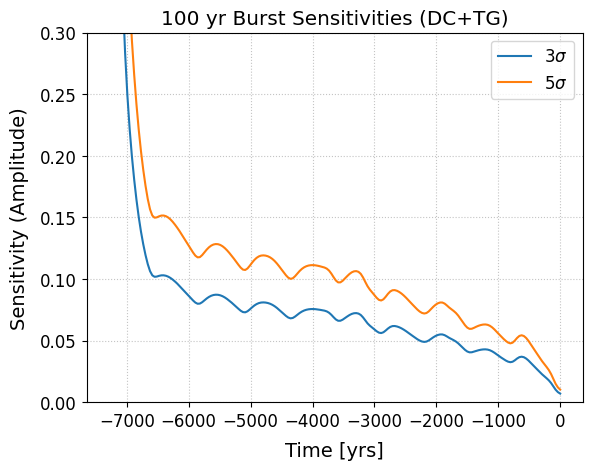

In [137]:
plt.plot(centers, S_3all, label=r'3$\sigma$')
plt.plot(centers, S_5all, label=r'5$\sigma$')
plt.xlabel('Time [yrs]')
plt.ylabel('Sensitivity (Amplitude)')
plt.ylim(0,0.3)
plt.legend()
plt.title('{} yr Burst Sensitivities (DC+TG)'.format(w))
plt.show()

In [84]:
phi_var = np.copy(flux_rand)
#phi_var += 1-phi_var[:,-1:]

A_var = np.sqrt(np.sum(phi_var @ A_B * phi_var, axis=-1))
chi2 = np.sum(phi_var @ X * phi_var, axis=-1)
chi2_TG = np.sum(phi_var @ X_TG * phi_var, axis=-1)
chi2_all = np.sum(phi_var @ X_all * phi_var, axis=-1)
S = A_var/np.sqrt(chi2)
S_TG = A_var/np.sqrt(chi2_TG)
S_all = A_var/np.sqrt(chi2_all)

S_3 = S * np.sqrt(stats.chi2.isf(stats.norm.sf(3)*2., len(z_samp) - len(f_true)) - len(z_samp) + len(f_true))
S_5 = S * np.sqrt(stats.chi2.isf(stats.norm.sf(5)*2., len(z_samp) - len(f_true)) - len(z_samp) + len(f_true))

S_3TG = S_TG * np.sqrt(stats.chi2.isf(stats.norm.sf(3)*2., len(z_samp_TG) - len(f_true)) - len(z_samp_TG) + len(f_true))
S_5TG = S_TG * np.sqrt(stats.chi2.isf(stats.norm.sf(5)*2., len(z_samp_TG) - len(f_true)) - len(z_samp_TG) + len(f_true))

S_3all = S_all * np.sqrt(stats.chi2.isf(stats.norm.sf(3)*2., len(z_samp) + len(z_samp_TG)  - len(f_true)) - len(z_samp) - len(z_samp_TG)  + len(f_true))
S_5all = S_all * np.sqrt(stats.chi2.isf(stats.norm.sf(5)*2., len(z_samp) + len(z_samp_TG)  - len(f_true)) - len(z_samp)  - len(z_samp_TG) + len(f_true))

# Sensitivity relative to General Amplitude
print('Dome C Sensitivity: \t\t\t {:.1f}% (3σ) \t {:.1f}% (5σ)'.format(np.median(S_3)*100, np.median(S_5)*100))
print()
print('Taylor Glacier Sensitivity: \t {:.1f}% (3σ) \t {:.1f}% (5σ)'.format(np.median(S_3TG)*100, np.median(S_5TG)*100))
print()
print('DC+TG Sensitivity: \t\t\t {:.1f}% (3σ) \t\t {:.1f}% (5σ)'.format(np.median(S_3all)*100, np.median(S_5all)*100))

Dome C Sensitivity: 			 7.8% (3σ) 	 11.8% (5σ)

Taylor Glacier Sensitivity: 	 334.1% (3σ) 	 515.6% (5σ)

DC+TG Sensitivity: 			 4.9% (3σ) 		 7.3% (5σ)


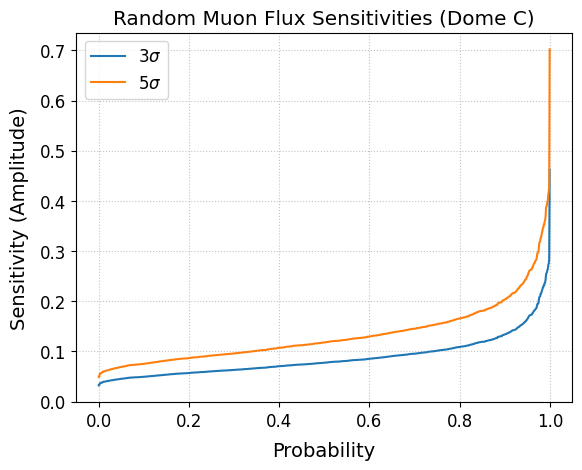

In [85]:
plt.plot((np.arange(N)+0.5)/N, np.sort(S_3), label=r'3$\sigma$')
plt.plot((np.arange(N)+0.5)/N, np.sort(S_5), label=r'5$\sigma$')
plt.xlabel('Probability')
plt.ylabel('Sensitivity (Amplitude)')
plt.legend()
plt.title('Random Muon Flux Sensitivities (Dome C)')
plt.show()

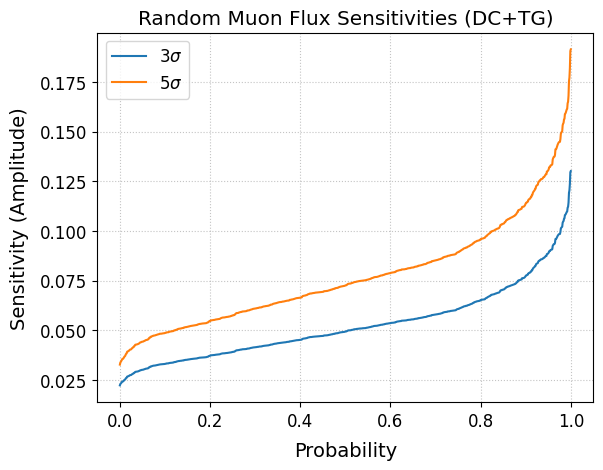

In [86]:
plt.plot((np.arange(N)+0.5)/N, np.sort(S_3all), label=r'3$\sigma$')
plt.plot((np.arange(N)+0.5)/N, np.sort(S_5all), label=r'5$\sigma$')
plt.xlabel('Probability')
plt.ylabel('Sensitivity (Amplitude)')
plt.legend()
plt.title('Random Muon Flux Sensitivities (DC+TG)')
plt.show()

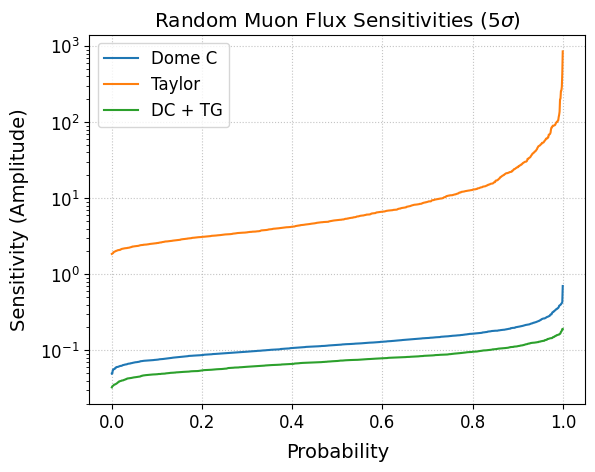

In [87]:
plt.plot((np.arange(N)+0.5)/N, np.sort(S_5), label='Dome C')
plt.plot((np.arange(N)+0.5)/N, np.sort(S_5TG), label='Taylor')
plt.plot((np.arange(N)+0.5)/N, np.sort(S_5all), label='DC + TG')
plt.xlabel('Probability')
plt.ylabel('Sensitivity (Amplitude)')
plt.yscale('log')
#plt.ylim(0,0.2)
plt.legend()
plt.title(r'Random Muon Flux Sensitivities (5$\sigma$)')
plt.show()

## Dividing Muon Flux into Sensitive & Insensitive Component

To learn about what shapes of muon flux we are senstive to vs insensitive to, it can be informative to divide our randomly generated fluxes into a Sensitive and Insensitive component.

The sensitive compoent of the muon flux ($\vec{\phi}_{A\parallel C}$) is the minimum amplitude flux which produces the exact same $^{14}$CO concentration as $\vec{\phi}$.

The insensitive component ($\vec{\phi}_{A\perp C}$) is everything else.


We first find the insensitive component by projecting our flux into Amplitude-space, then pseudoinverting to a basis of the insensitive subspace of $\vec{\phi}$, before transforming back into $\phi$-space:

$$\vec{\phi}_{A\perp C} = \Phi_\perp (A\Phi_\perp)^+ A \vec{\phi}$$
$$= \Phi_\perp (\Phi_\perp^T A^T A \Phi_\perp)^{-1} \Phi_\perp^T A^T A \vec{\phi}$$
$$= \Phi_\perp (\Phi_\perp^T A_B \Phi_\perp)^{-1} \Phi_\perp^T A_B \vec{\phi}$$
$$= P_{A\perp C} \vec{\phi}$$

$$P_{A\perp C} = \Phi_\perp (\Phi_\perp^T A_B \Phi_\perp)^{-1} \Phi_\perp^T A_B$$

$\Phi_\perp$ is a set of linearly-independent basis vectors for the range of $P_{\perp} = I - P_{\parallel} = I - C^+C = I - C^T (CC^T)^{-1}C$.

Note, for the inverse to exist, $A\Phi_\perp$ must have the same rank in its domain and range (# time bins - # data points).  That is, the transformation of $\Phi_\perp$ into Amplitude-space must be injective, or else the minimum-amplitude $\vec{\phi}$ we're searching for won't be unique.  This proves to be a problem if we use a blur in our definition for the Amplitude, which significantly reduces the rank.  In other words, a definition of Amplitude that uses blur gives too much freedom for the sensitive flux to have wacky, unconstrained behavior, so we'll remove it when looking for the sensitive component of the flux.

The result, $\vec{\phi}_{A\perp C}$, is a flux vector with 0 contribution to observed $^{14}$CO levels ($C\vec{\phi}_{A\perp C} = \vec{0}$), and whose corresponding amplitude vector $A\vec{\phi}_{A\perp C}$ is the projection of $A\vec{\phi}$ onto the range of $A\Phi_\perp$ (that is, the component of ampiltude which can be removed without changing $\vec{c}$).

Removing this vector from our original $\vec{\phi}$ gives a muon flux with the same $\vec{c}$ which minimizes the amplitude!

$$\vec{\phi}_{A\parallel C} = \vec{\phi} - \vec{\phi}_{A\perp C}$$
$$= (I-P_{A\perp C}) \vec{\phi}$$
$$= P_{A\parallel C} \vec{\phi}$$

$$P_{A\parallel C} = I - \Phi_\perp (\Phi_\perp^T A_B \Phi_\perp)^{-1} \Phi_\perp^T A_B$$

In [88]:
Proj_C = CO_response_all @ np.linalg.inv(CO_response_all.T @ CO_response_all) @ CO_response_all.T

In [89]:
#Phi_par = orth(Proj_C, 0.1)

In [90]:
#Phi_par.shape

In [91]:
# This basis doesn't have to be orthonormal; just linearly independent
# There's probably a faster way to get this matrix
Phi_perp = orth(np.identity(len(t))-Proj_C, 0.1)

In [92]:
Phi_perp.shape

(7711, 7693)

In [209]:
#Proj_Apar = Phi_par @ np.linalg.inv(Phi_par.T @ A_noB @ Phi_par) @ Phi_par.T @ A_noB
Proj_Apar = np.identity(len(t)) - Phi_perp @ np.linalg.inv(Phi_perp.T @ A_noB @ Phi_perp) @ Phi_perp.T @ A_noB

In [210]:
#Proj_ABperp = Phi_perp @ np.linalg.inv(Phi_perp.T @ A_B @ Phi_perp) @ Phi_perp.T @ A_B

In [211]:
#Proj_ABpar = Phi_par @ np.linalg.inv(Phi_par.T @ A_B @ Phi_par) @ Phi_par.T @ A_B
#Proj_ABpar = np.identity(len(t)) - Proj_ABperp

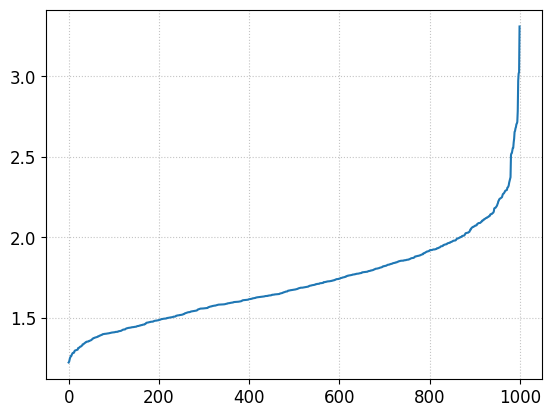

In [223]:
plt.plot(np.sort(np.sqrt(np.sum(flux_rand @ A_noB * flux_rand, axis=-1))/np.sqrt(np.sum(flux_rand @ Proj_Apar.T @ A_noB * (flux_rand @ Proj_Apar.T), axis=-1))))

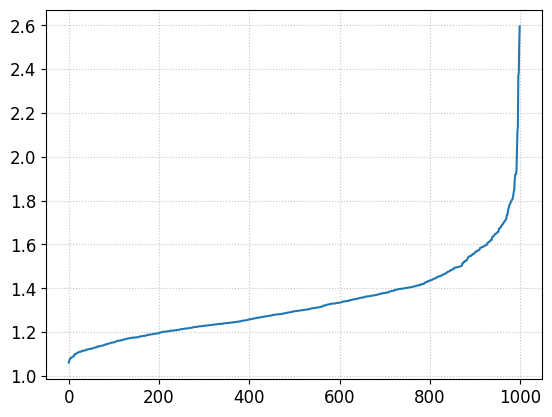

In [234]:
plt.plot(np.sort(np.sqrt(np.sum(flux_rand @ A_noB * flux_rand, axis=-1))/np.sqrt(np.sum(flux_rand @ Proj_Apar.T @ A_noB * (flux_rand @ Proj_Apar.T), axis=-1))))

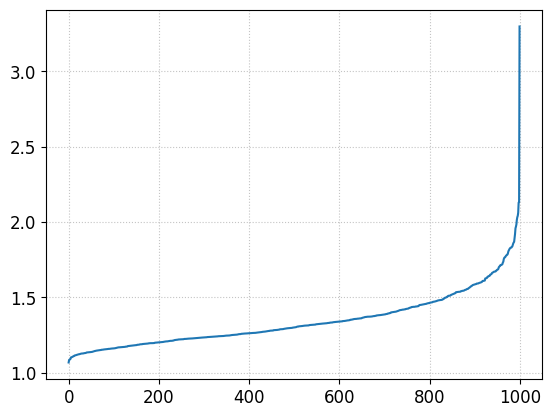

In [230]:
plt.plot(np.sort(np.sqrt(np.sum(flux_rand @ A_noB * flux_rand, axis=-1))/np.sqrt(np.sum(flux_rand @ Proj_Apar.T @ A_noB * (flux_rand @ Proj_Apar.T), axis=-1))))

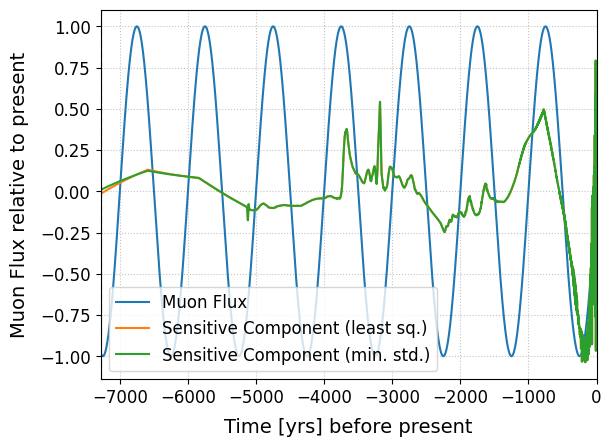

In [257]:
phi = flux_rand[1]#*0.1
#phi += 1-phi[-1]
#phi = 0*t+1
phi = np.sin(t/(1000)*np.pi*2)
plt.plot(t,phi, label='Muon Flux')
plt.plot(t, Proj_C @ (phi-np.mean(phi))+np.mean(phi), label='Sensitive Component (least sq.)')
plt.plot(t, Proj_Apar @ (phi), label='Sensitive Component (min. std.)')
#plt.plot(t, phi - Proj_Apar @ (phi), label='Insensitive Component')
plt.axvline(t_bins_DC[0], ls='--', c='k')

plt.xlim(t_bins_DC[0],t_bins_DC[-1])
plt.xlabel('Time [yrs] before present')
plt.ylabel('Muon Flux relative to present')
plt.legend()

plt.show()

In [237]:
phi_sens = Proj_Apar @ phi

In [238]:
np.sqrt(np.sum(phi @ A_noB * phi, axis=-1))

np.float64(1.4828276943977985)

In [239]:
np.sqrt(np.sum((Proj_C @ (phi-np.mean(phi))+np.mean(phi)) @ A_noB * (Proj_C @ (phi-np.mean(phi))+np.mean(phi)), axis=-1))

np.float64(1.2063588140824717)

In [240]:
np.sqrt(np.sum(phi_sens @ A_noB * phi_sens, axis=-1))

np.float64(1.204060507421634)

In [241]:
np.sum((Proj_C @ phi)**2)

np.float64(1.4497762479049694)

In [242]:
np.sum((phi_sens)**2)

np.float64(1.4497762453899417)

In [243]:
CO_response.T @ phi

array([-0.15280322, -0.27158926, -0.21544515, -0.31571336, -0.37202899,
       -0.27372666, -0.09834581, -0.0858455 , -0.10557227, -0.03212701])

In [244]:
CO_response.T @ Proj_C @ phi

array([-0.15280322, -0.27158926, -0.21544515, -0.31571336, -0.37202899,
       -0.27372666, -0.09834581, -0.0858455 , -0.10557227, -0.03212701])

In [245]:
CO_response.T @ phi_sens

array([-0.15280322, -0.27158926, -0.21544515, -0.31571336, -0.37202899,
       -0.27372666, -0.09834581, -0.0858455 , -0.10557227, -0.03212701])